# Try autoencoders for clustering

In [70]:
from utils import *
# Loading sample
df_2_hME1_scaled = pd.read_csv("Experiment/hme1_2/Data/Processed/Full_dataset_2_hTERT_HME1_functional_names_diff_scaled_phPlus.tsv", sep="\t").fillna(0)

print(f"The Dataframe shape: {df_2_hME1_scaled.shape}")

nreps_df = filter_replicates(df_2_hME1_scaled, n_reps=2)
localized_sites_df = filter_site_localizations(nreps_df, loc_sites=True)
df_filtered = filter_dynamics_extremes(df = localized_sites_df,
                                       data_type="log2_FC",
                                       threshold=0.5,
                                       exclude_full=True)
print(f"Original Dataframe shape: {df_2_hME1_scaled.shape}"
      f"\nnreps_df: {nreps_df.shape}"
      f"\nlocalized_sites_df: {localized_sites_df.shape}"
      f"\ndf_filtered: {df_filtered.shape}")

The Dataframe shape: (50002, 481)
Original Dataframe shape: (50002, 481)
nreps_df: (33718, 481)
localized_sites_df: (24268, 481)
df_filtered: (5614, 481)


In [71]:
testing_1000 = df_filtered.head(1000).copy()

data_type = "log2_FC"
column_names = testing_1000.columns.tolist()
column_selection = [element for element in column_names if element.startswith(f"{data_type}") and "full" not in element]

print(f"Column selection: {column_selection}\n")

X, labels = reshape_df(testing_1000, time_series= column_selection, dimensions=3, len_time_serie=6, transpose= False, labels="site", verbose=False)

print(X.shape) # PyTorch expects (batch, channels, length) for Conv1D --> transpose = False

Column selection: ['log2_FC_EGF_starve', 'log2_FC_EGF_2', 'log2_FC_EGF_5', 'log2_FC_EGF_10', 'log2_FC_EGF_15', 'log2_FC_EGF_90', 'log2_FC_INS_starve', 'log2_FC_INS_2', 'log2_FC_INS_5', 'log2_FC_INS_10', 'log2_FC_INS_15', 'log2_FC_INS_90', 'log2_FC_EGFnINS_starve', 'log2_FC_EGFnINS_2', 'log2_FC_EGFnINS_5', 'log2_FC_EGFnINS_10', 'log2_FC_EGFnINS_15', 'log2_FC_EGFnINS_90']

(1000, 3, 6)


## Try 1D CNN auto encoder
### with K-Means

Epoch 10/50 — Loss: 0.0423
Epoch 20/50 — Loss: 0.0205
Epoch 30/50 — Loss: 0.0140
Epoch 40/50 — Loss: 0.0115
Epoch 50/50 — Loss: 0.0106
k=2 — Silhouette: 0.383
k=3 — Silhouette: 0.408
k=4 — Silhouette: 0.347
k=5 — Silhouette: 0.357
k=6 — Silhouette: 0.355
k=7 — Silhouette: 0.330
k=8 — Silhouette: 0.332
k=9 — Silhouette: 0.291
k=10 — Silhouette: 0.300
k=11 — Silhouette: 0.217
k=12 — Silhouette: 0.199
k=13 — Silhouette: 0.208
k=14 — Silhouette: 0.199

Best k: 3


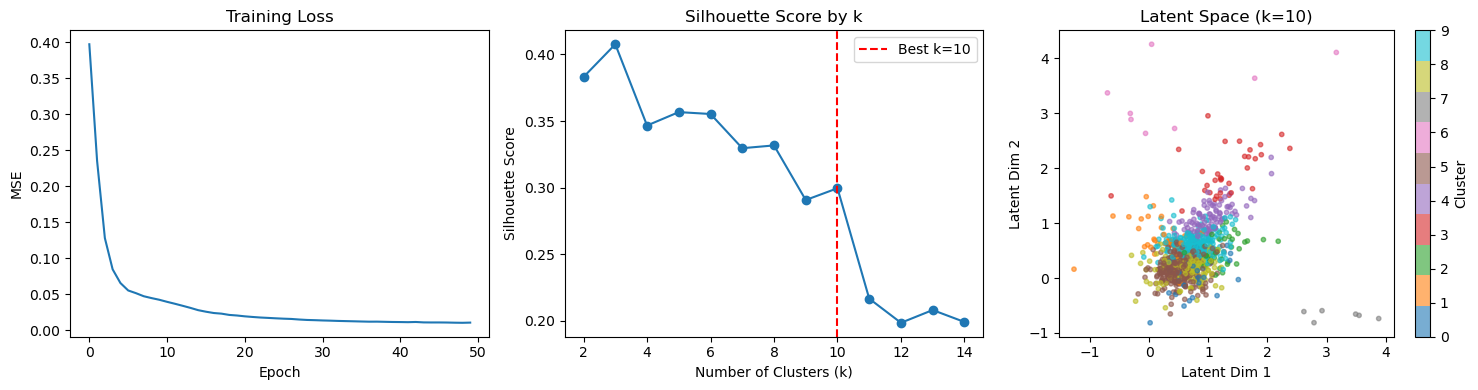

In [72]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

X_tensor = torch.tensor(X, dtype=torch.float32)
dataset = TensorDataset(X_tensor)
loader = DataLoader(dataset, batch_size=64, shuffle=True)


# ── 1D CNN Autoencoder ───────────────────────────────────────────────────────
class CNNAutoencoder(nn.Module):
    def __init__(self, in_channels=3, latent_dim=8):
        super().__init__()

        # Encoder: (batch, 3, 6) → (batch, latent_dim)
        self.encoder = nn.Sequential(
            nn.Conv1d(in_channels, 16, kernel_size=3, padding=1),  # → (batch, 16, 6)
            nn.ReLU(),
            nn.Conv1d(16, 32, kernel_size=3, padding=1),           # → (batch, 32, 6)
            nn.ReLU(),
            nn.Flatten(),                                           # → (batch, 32*6=192)
            nn.Linear(192, latent_dim)                             # → (batch, latent_dim)
        )

        # Decoder: (batch, latent_dim) → (batch, 3, 6)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 192),                            # → (batch, 192)
            nn.ReLU(),
            nn.Unflatten(1, (32, 6)),                              # → (batch, 32, 6)
            nn.ConvTranspose1d(32, 16, kernel_size=3, padding=1),  # → (batch, 16, 6)
            nn.ReLU(),
            nn.ConvTranspose1d(16, in_channels, kernel_size=3, padding=1),  # → (batch, 3, 6)
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z), z


# ── Training ─────────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNNAutoencoder(in_channels=3, latent_dim=8).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

epochs = 50
losses = []

model.train()
for epoch in range(epochs):
    epoch_loss = 0
    for (batch,) in loader:
        batch = batch.to(device)
        recon, _ = model(batch)
        loss = criterion(recon, batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(loader)
    losses.append(avg_loss)
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs} — Loss: {avg_loss:.4f}")


# ── Extract latent vectors ────────────────────────────────────────────────────
model.eval()
with torch.no_grad():
    _, latent = model(X_tensor.to(device))
latent_np = latent.cpu().numpy()  # (1000, latent_dim)


# ── K-Means clustering ────────────────────────────────────────────────────────
# Find optimal k using silhouette score
k_range = range(2, 15)
silhouette_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(latent_np)
    score = silhouette_score(latent_np, labels)
    silhouette_scores.append(score)
    print(f"k={k} — Silhouette: {score:.3f}")

best_k = k_range[np.argmax(silhouette_scores)]
print(f"\nBest k: {best_k}")

# Final clustering with best k
best_k = 10
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(latent_np)


# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Training loss
axes[0].plot(losses)
axes[0].set_title("Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE")

# 2. Silhouette scores
axes[1].plot(list(k_range), silhouette_scores, marker='o')
axes[1].set_title("Silhouette Score by k")
axes[1].set_xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].axvline(best_k, color='red', linestyle='--', label=f'Best k={best_k}')
axes[1].legend()

# 3. Latent space (first 2 dims)
scatter = axes[2].scatter(latent_np[:, 0], latent_np[:, 1], c=cluster_labels, cmap='tab10', alpha=0.6, s=10)
axes[2].set_title(f"Latent Space (k={best_k})")
axes[2].set_xlabel("Latent Dim 1")
axes[2].set_ylabel("Latent Dim 2")
plt.colorbar(scatter, ax=axes[2], label="Cluster")

plt.tight_layout()
# plt.savefig("autoencoder_clustering.png", dpi=150)
plt.show()

In [73]:
testing_1000.insert(0, "clustering_log2_FC_Kmeans", cluster_labels)

### DBSCAN

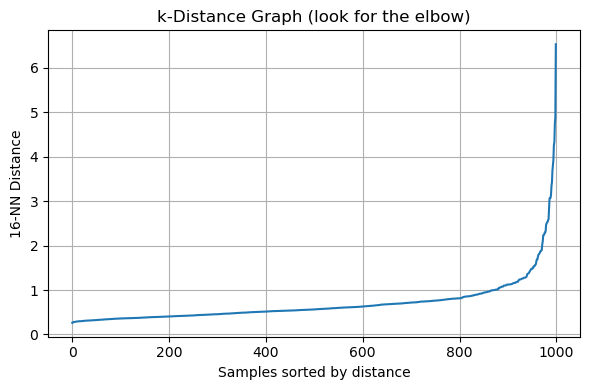

Auto-estimated eps: 1.1220
Clusters found: 1
Noise points:   45 (4.5%)


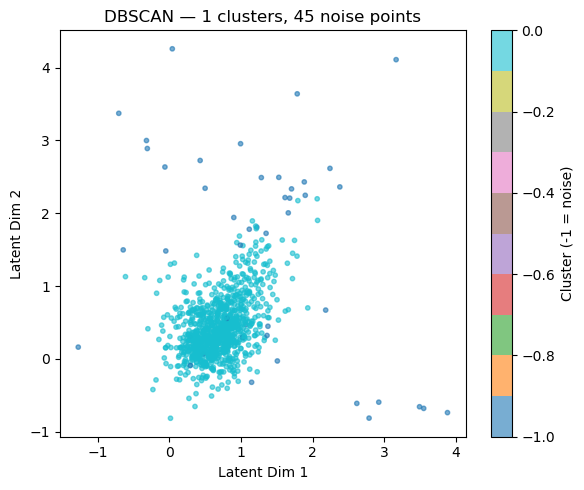

In [74]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

# ── Find optimal eps using k-distance plot ────────────────────────────────────
# Rule of thumb: min_samples = 2 * latent_dim
min_samples = 2 * 8  # adjust if you changed latent_dim

nbrs = NearestNeighbors(n_neighbors=min_samples).fit(latent_np)
distances, _ = nbrs.kneighbors(latent_np)
k_distances = np.sort(distances[:, -1])  # distance to the k-th nearest neighbor

# Plot k-distance graph to visually pick eps
plt.figure(figsize=(6, 4))
plt.plot(k_distances)
plt.title("k-Distance Graph (look for the elbow)")
plt.xlabel("Samples sorted by distance")
plt.ylabel(f"{min_samples}-NN Distance")
plt.grid(True)
plt.tight_layout()
plt.show()

# ── Run DBSCAN ────────────────────────────────────────────────────────────────
# Set eps at the elbow point from the plot above
eps = np.percentile(k_distances, 90)  # rough automatic estimate — tune manually after
print(f"Auto-estimated eps: {eps:.4f}")

db = DBSCAN(eps=eps, min_samples=min_samples)
cluster_labels = db.fit_predict(latent_np)

n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
n_noise = (cluster_labels == -1).sum()
print(f"Clusters found: {n_clusters}")
print(f"Noise points:   {n_noise} ({100 * n_noise / len(cluster_labels):.1f}%)")

# Silhouette score (only valid if more than 1 cluster and not all noise)
if n_clusters > 1:
    mask = cluster_labels != -1  # exclude noise points
    score = silhouette_score(latent_np[mask], cluster_labels[mask])
    print(f"Silhouette score (excl. noise): {score:.3f}")

# ── Plot ──────────────────────────────────────────────────────────────────────
plt.figure(figsize=(6, 5))
scatter = plt.scatter(latent_np[:, 0], latent_np[:, 1],
                      c=cluster_labels, cmap='tab10', alpha=0.6, s=10)
plt.title(f"DBSCAN — {n_clusters} clusters, {n_noise} noise points")
plt.xlabel("Latent Dim 1")
plt.ylabel("Latent Dim 2")
plt.colorbar(scatter, label="Cluster (-1 = noise)")
plt.tight_layout()
plt.show()

### GMM (soft cluster addignmet with probalilities)

k=2 — BIC: 5086.8  AIC: 4650.0
k=3 — BIC: 4112.2  AIC: 3454.6
k=4 — BIC: 3640.4  AIC: 2761.9
k=5 — BIC: 3509.9  AIC: 2410.6
k=6 — BIC: 3159.3  AIC: 1839.1
k=7 — BIC: 3137.6  AIC: 1596.6
k=8 — BIC: 3039.9  AIC: 1278.0
k=9 — BIC: 3121.8  AIC: 1139.1
k=10 — BIC: 3098.8  AIC: 895.3
k=11 — BIC: 3317.5  AIC: 893.0
k=12 — BIC: 3408.3  AIC: 763.0
k=13 — BIC: 3463.7  AIC: 597.6
k=14 — BIC: 3638.4  AIC: 551.4

Best k (BIC): 8
Best k (AIC): 14
Silhouette score: 0.147
Mean assignment confidence: 0.916


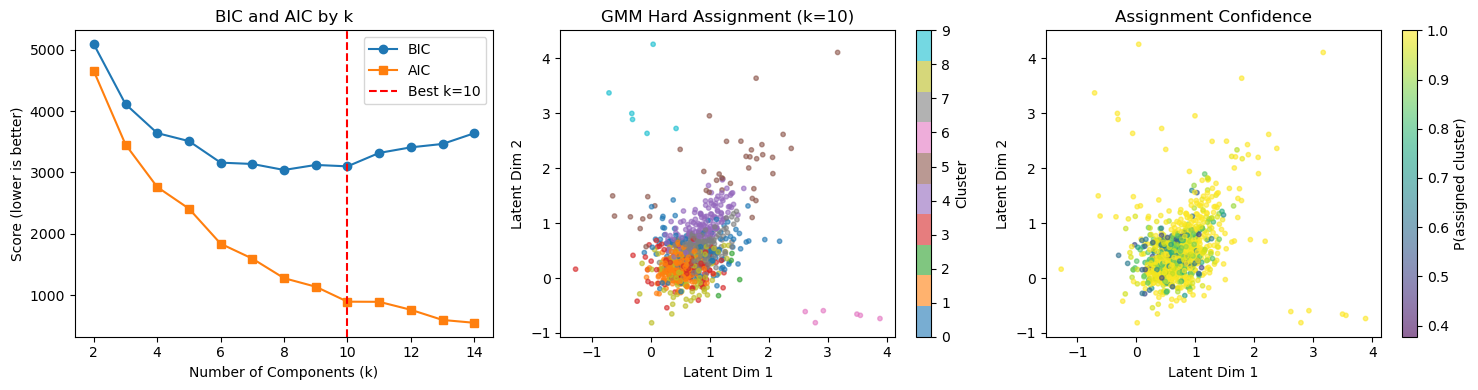

In [76]:
from sklearn.mixture import GaussianMixture

# ── Find optimal n_components using BIC and AIC ───────────────────────────────
k_range = range(2, 15)
bic_scores = []
aic_scores = []

for k in k_range:
    gmm = GaussianMixture(n_components=k, random_state=42, n_init=5)
    gmm.fit(latent_np)
    bic_scores.append(gmm.bic(latent_np))
    aic_scores.append(gmm.aic(latent_np))
    print(f"k={k} — BIC: {gmm.bic(latent_np):.1f}  AIC: {gmm.aic(latent_np):.1f}")

best_k_bic = k_range[np.argmin(bic_scores)]
best_k_aic = k_range[np.argmin(aic_scores)]
print(f"\nBest k (BIC): {best_k_bic}")
print(f"Best k (AIC): {best_k_aic}")

# ── Fit final GMM ─────────────────────────────────────────────────────────────
# BIC is generally more reliable — use best_k_aic if you prefer less penalization
best_k = best_k_bic
best_k = 10

gmm = GaussianMixture(n_components=best_k, random_state=42, n_init=5)
gmm.fit(latent_np)

cluster_labels = gmm.predict(latent_np)           # hard assignment
probs = gmm.predict_proba(latent_np)              # soft assignment (1000, k)

# Silhouette score
score = silhouette_score(latent_np, cluster_labels)
print(f"Silhouette score: {score:.3f}")

# Confidence: probability of the assigned cluster
confidence = probs.max(axis=1)
print(f"Mean assignment confidence: {confidence.mean():.3f}")

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. BIC and AIC scores
axes[0].plot(list(k_range), bic_scores, marker='o', label='BIC')
axes[0].plot(list(k_range), aic_scores, marker='s', label='AIC')
axes[0].axvline(best_k, color='red', linestyle='--', label=f'Best k={best_k}')
axes[0].set_title("BIC and AIC by k")
axes[0].set_xlabel("Number of Components (k)")
axes[0].set_ylabel("Score (lower is better)")
axes[0].legend()

# 2. Latent space colored by hard cluster assignment
scatter = axes[1].scatter(latent_np[:, 0], latent_np[:, 1],
                          c=cluster_labels, cmap='tab10', alpha=0.6, s=10)
axes[1].set_title(f"GMM Hard Assignment (k={best_k})")
axes[1].set_xlabel("Latent Dim 1")
axes[1].set_ylabel("Latent Dim 2")
plt.colorbar(scatter, ax=axes[1], label="Cluster")

# 3. Latent space colored by confidence
scatter2 = axes[2].scatter(latent_np[:, 0], latent_np[:, 1],
                           c=confidence, cmap='viridis', alpha=0.6, s=10)
axes[2].set_title("Assignment Confidence")
axes[2].set_xlabel("Latent Dim 1")
axes[2].set_ylabel("Latent Dim 2")
plt.colorbar(scatter2, ax=axes[2], label="P(assigned cluster)")

plt.tight_layout()
plt.show()

In [77]:
testing_1000.insert(0,"clustering_log2_FC_GMM", cluster_labels)